# Dark Emulator Tutorial

This tutorial demonstrates how to use the Dark Emulator integration in cloelib.

Dark Emulator provides fast, accurate emulation of:
- Nonlinear matter power spectrum P(k,z)
- Halo statistics (mass function, bias, correlation functions)
- HOD-based galaxy statistics (w_p, ΔΣ, ξ_gg, ξ_gm)

## Classes Overview

| Class | Dark Emulator Module | Primary Output |
|-------|---------------------|----------------|
| `DarkEmuNonLinearPerturbations` | `de_interface.base_class` | P(k, z), D(z), f(z), σ8 |
| `DarkEmuHaloPerturbations` | `de_interface.halo` | dn/dlnM, b(M), ξ_hm, ξ_hh, ΔΣ_halo |
| `DarkEmuHODPerturbations` | `model_hod` | w_p, ΔΣ, ξ_gg, ξ_gm |

## References
- Nishimichi et al. (2019): Dark Quest. I. Fast and Accurate Emulation
- Miyatake et al. (2022): HSC-Y1 cosmology with emulator-based halo model
- Miyatake et al. (2023): HSC-Y3 3x2pt cosmology analysis

In [22]:
# Setup paths (run this cell first)
import sys
from pathlib import Path

# Find CLOE repo root (directory that contains cloelib, cloelike, dark_emulator_public)
NOTEBOOK_DIR = Path.cwd()
CLOE_ROOT = NOTEBOOK_DIR
for _ in range(6):
    if (CLOE_ROOT / "cloelib").is_dir():
        break
    CLOE_ROOT = CLOE_ROOT.parent
else:
    raise FileNotFoundError("CLOE root not found: run the notebook from inside the CLOE repo.")

sys.path.insert(0, str(CLOE_ROOT / "cloelib"))
sys.path.insert(0, str(CLOE_ROOT / "cloelike"))
sys.path.insert(0, str(CLOE_ROOT / "dark_emulator_public"))

# General imports
import numpy as np
import matplotlib.pyplot as plt

# cloelib imports
from cloelib.cosmology.camb_cosmology import CAMBBackground
from cloelib.cosmology.darkemu_cosmology import (
    DarkEmuNonLinearPerturbations,
    DarkEmuHaloPerturbations,
    DarkEmuHODPerturbations,
)
from cloelib.observables.darkemu_hod import DarkEmuHODParameters
from cloelib.auxiliary.darkemu_utils import (
    background_to_darkemu_cparam,
    darkemu_cparam_to_dict,
    DARKEMU_PARAM_RANGES,
)

print(f"CLOE_ROOT: {CLOE_ROOT}")
print("Imports successful!")

CLOE_ROOT: /home/ryuseikano/Euclid/CLOE
Imports successful!


## 1. Setup: Cosmological Parameters

Dark Emulator has specific requirements:
- **Flat universe**: Ω_k = 0
- **Constant w**: w_a = 0
- **Fixed neutrino mass**: ω_ν = 0.00064 (internally)

Parameters must be within the training range:

In [2]:
# Print Dark Emulator parameter ranges
print("Dark Emulator Training Ranges:")
print("=" * 50)
for param, (low, high) in DARKEMU_PARAM_RANGES.items():
    print(f"  {param:12s}: [{low:.6f}, {high:.6f}]")

Dark Emulator Training Ranges:
  omega_b     : [0.021138, 0.023363]
  omega_c     : [0.107820, 0.131780]
  Omega_de    : [0.547520, 0.821280]
  ln10^10As   : [2.475200, 3.712800]
  ns          : [0.916275, 1.012725]
  w           : [-1.200000, -0.800000]


In [3]:
# Define cosmological parameters (Planck-like)
cosmo_params = {
    'H0': 67.0,
    'Omega_cdm0': 0.27,
    'Omega_b0': 0.049,
    'Omega_k0': 0.0,      # Must be 0 for Dark Emulator
    'w0': -1.0,
    'wa': 0.0,            # Must be 0 for Dark Emulator
    'As': 2.1e-9,
    'ns': 0.96,
    'mnu': 0.06,          # Will use Dark Emulator's fixed value internally
    'N_mnu': 1,
    'gamma_MG': 0.55,
}

# Create background cosmology
background = CAMBBackground(**cosmo_params)
print(f"Background created: H0 = {background.H0}, Ω_cdm = {background.Omega_cdm0}")

Background created: H0 = 67.0, Ω_cdm = 0.27


In [4]:
# Convert to Dark Emulator cparam format
cparam = background_to_darkemu_cparam(background)
cparam_dict = darkemu_cparam_to_dict(cparam)

print("\nDark Emulator cparam:")
print("=" * 50)
for name, value in cparam_dict.items():
    print(f"  {name:12s}: {value:.6f}")


Dark Emulator cparam:
  omega_b     : 0.021996
  omega_c     : 0.121203
  Omega_de    : 0.679574
  ln10^10As   : 3.044522
  ns          : 0.960000
  w           : -1.000000


/tmp/ipykernel_1139587/3002700217.py:2: UserWarning: Neutrino density mismatch: input omega_nu = 0.000000, but Dark Emulator assumes fixed omega_nu = 0.00064. Dark Emulator will use its internal fixed value regardless of input.
  cparam = background_to_darkemu_cparam(background)


---
## 2. DarkEmuNonLinearPerturbations

The base class for nonlinear matter power spectrum P(k,z).

**Available methods:**
- `matter_power_spectrum(z, k)` - P(k,z)
- `growth_factor(z)` - D(z)
- `growth_rate(z)` - f(z) = d ln D / d ln a
- `get_sigma8(z)` - σ8(z)

In [5]:
# Initialize DarkEmuNonLinearPerturbations
redshifts = np.array([0.0, 0.5, 1.0, 1.5])

pert_nl = DarkEmuNonLinearPerturbations(
    background=background,
    redshifts=redshifts,
    validate_params=True,  # Check if params are within training range
)

print(f"σ8(z=0) = {pert_nl.get_sigma8(z=0.0):.4f}")

σ8(z=0) = 0.8150


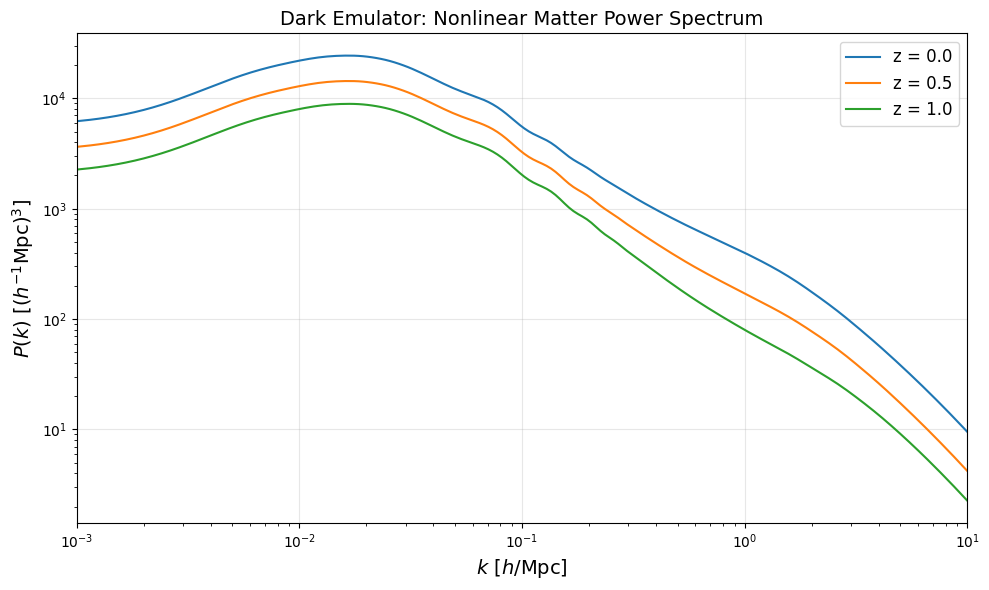

In [6]:
# Compute matter power spectrum
k = np.logspace(-3, 1, 200)  # h/Mpc
z_plot = [0.0, 0.5, 1.0]

fig, ax = plt.subplots(figsize=(10, 6))

for z in z_plot:
    Pk = pert_nl.matter_power_spectrum(np.array([z]), k)
    ax.loglog(k, Pk[0], label=f'z = {z}')

ax.set_xlabel(r'$k$ [$h$/Mpc]', fontsize=14)
ax.set_ylabel(r'$P(k)$ [$(h^{-1}$Mpc$)^3$]', fontsize=14)
ax.set_title('Dark Emulator: Nonlinear Matter Power Spectrum', fontsize=14)
ax.legend(fontsize=12)
ax.set_xlim(1e-3, 10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

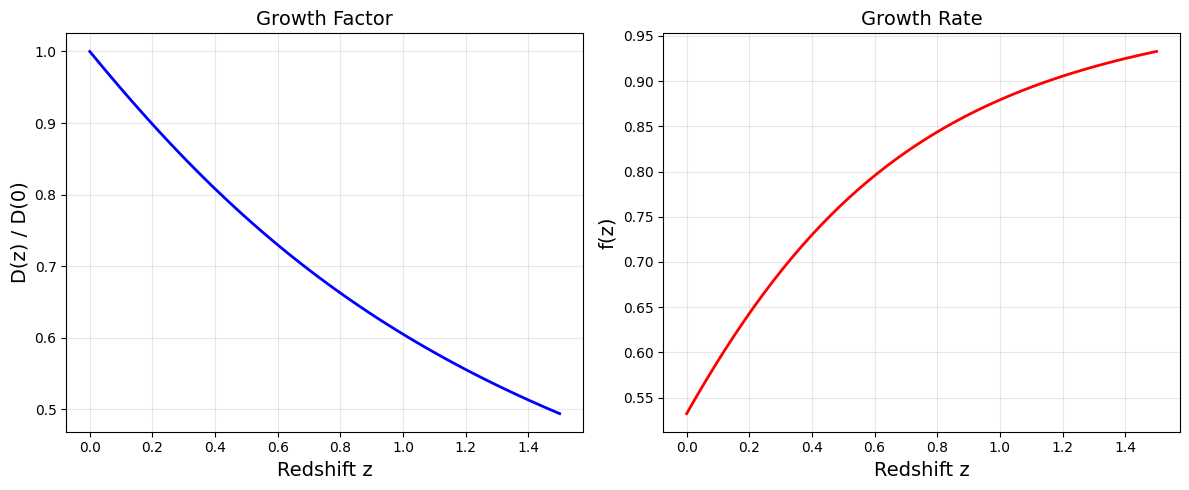

In [7]:
# Growth factor and growth rate
z_arr = np.linspace(0, 1.5, 50)

D_z = pert_nl.growth_factor(z_arr)
f_z = pert_nl.growth_rate(z_arr)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(z_arr, D_z, 'b-', lw=2)
axes[0].set_xlabel('Redshift z', fontsize=14)
axes[0].set_ylabel('D(z) / D(0)', fontsize=14)
axes[0].set_title('Growth Factor', fontsize=14)
axes[0].grid(True, alpha=0.3)

axes[1].plot(z_arr, f_z, 'r-', lw=2)
axes[1].set_xlabel('Redshift z', fontsize=14)
axes[1].set_ylabel('f(z)', fontsize=14)
axes[1].set_title('Growth Rate', fontsize=14)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 3. DarkEmuHaloPerturbations

Extends the base class with halo statistics for mass-threshold samples.

**Available methods:**
- `halo_matter_correlation(r, z, M_min)` - ξ_hm(r)
- `halo_halo_correlation(r, z, M_min)` - ξ_hh(r)
- `halo_mass_function(z)` - dn/dlnM
- `halo_bias(M_min, z)` - linear bias b(M)
- `delta_sigma_halo(R, z, M_min)` - ΔΣ for halos
- `projected_correlation_halo(R, z, M_min)` - w_p for halos
- `mass_to_density(M_min, z)` - cumulative number density
- `density_to_mass(n, z)` - inverse lookup

In [8]:
# Initialize DarkEmuHaloPerturbations
pert_halo = DarkEmuHaloPerturbations(
    background=background,
    redshifts=redshifts,
)

print("DarkEmuHaloPerturbations initialized")

DarkEmuHaloPerturbations initialized


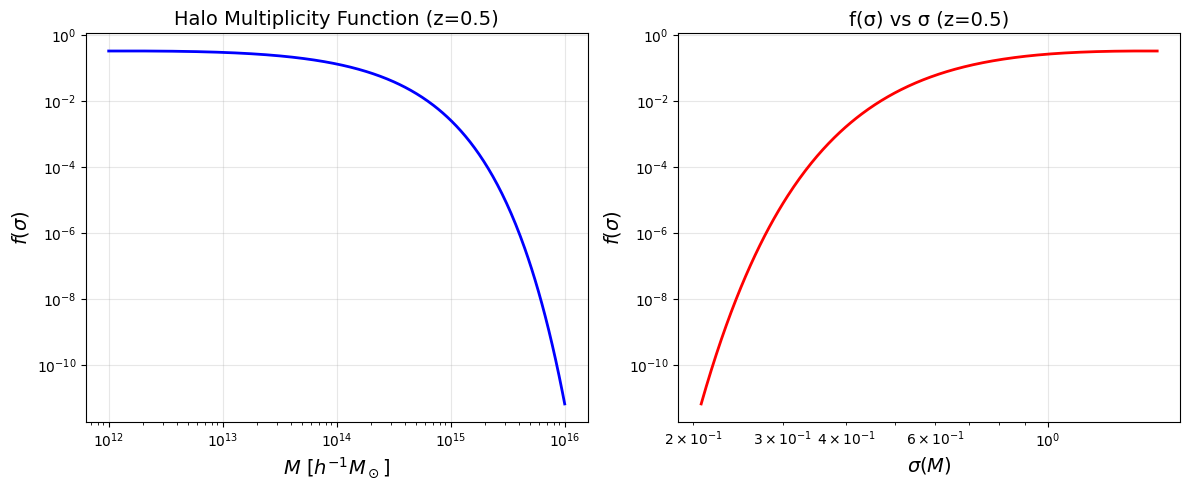

In [9]:
# Halo mass function
z = 0.5
M, sigma, f_sigma = pert_halo.halo_mass_function(z)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].loglog(M, f_sigma, 'b-', lw=2)
axes[0].set_xlabel(r'$M$ [$h^{-1} M_\odot$]', fontsize=14)
axes[0].set_ylabel(r'$f(\sigma)$', fontsize=14)
axes[0].set_title(f'Halo Multiplicity Function (z={z})', fontsize=14)
axes[0].grid(True, alpha=0.3)

axes[1].loglog(sigma, f_sigma, 'r-', lw=2)
axes[1].set_xlabel(r'$\sigma(M)$', fontsize=14)
axes[1].set_ylabel(r'$f(\sigma)$', fontsize=14)
axes[1].set_title(f'f(σ) vs σ (z={z})', fontsize=14)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

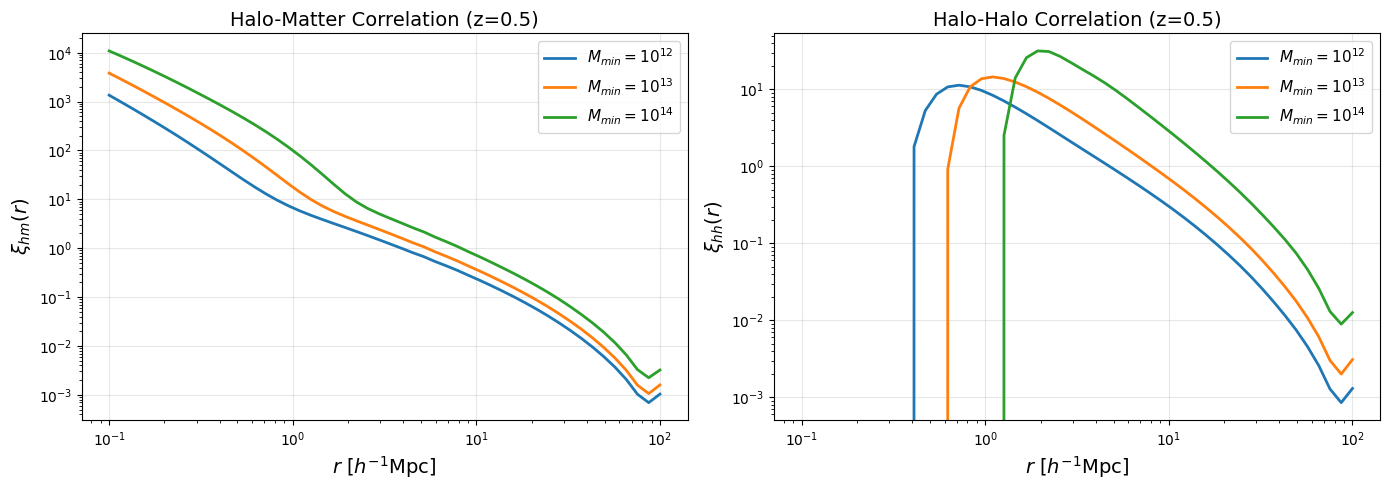

In [10]:
# Halo-matter and halo-halo correlation functions
r = np.logspace(-1, 2, 50)  # h^-1 Mpc
z = 0.5
M_min_values = [1e12, 1e13, 1e14]  # h^-1 M_sun

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for M_min in M_min_values:
    xi_hm = pert_halo.halo_matter_correlation(r, z, M_min)
    xi_hh = pert_halo.halo_halo_correlation(r, z, M_min)
    
    label = f'$M_{{min}} = 10^{{{np.log10(M_min):.0f}}}$'
    axes[0].loglog(r, xi_hm, lw=2, label=label)
    axes[1].loglog(r, xi_hh, lw=2, label=label)

axes[0].set_xlabel(r'$r$ [$h^{-1}$Mpc]', fontsize=14)
axes[0].set_ylabel(r'$\xi_{hm}(r)$', fontsize=14)
axes[0].set_title(f'Halo-Matter Correlation (z={z})', fontsize=14)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel(r'$r$ [$h^{-1}$Mpc]', fontsize=14)
axes[1].set_ylabel(r'$\xi_{hh}(r)$', fontsize=14)
axes[1].set_title(f'Halo-Halo Correlation (z={z})', fontsize=14)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

/home/ryuseikano/Euclid/CLOE/dark_emulator_public/dark_emulator/darkemu/hmf.py:100: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  dens = integrate.quad(lambda t: np.exp(


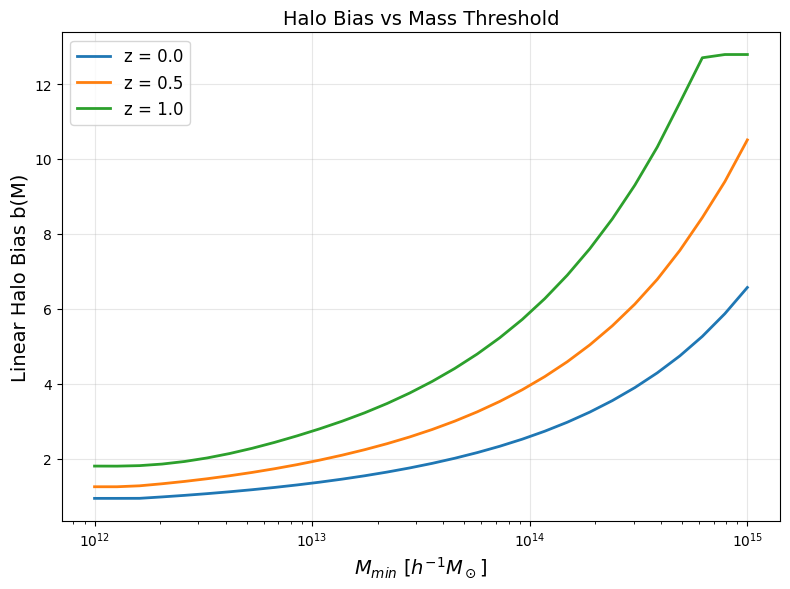

In [11]:
# Halo bias as a function of mass threshold
z_values = [0.0, 0.5, 1.0]
M_min_arr = np.logspace(12, 15, 30)

fig, ax = plt.subplots(figsize=(8, 6))

for z in z_values:
    # halo_bias returns array with extra dimensions, squeeze to 1D
    bias = np.array([np.squeeze(pert_halo.halo_bias(M, z)) for M in M_min_arr])
    ax.semilogx(M_min_arr, bias, lw=2, label=f'z = {z}')

ax.set_xlabel(r'$M_{min}$ [$h^{-1} M_\odot$]', fontsize=14)
ax.set_ylabel('Linear Halo Bias b(M)', fontsize=14)
ax.set_title('Halo Bias vs Mass Threshold', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

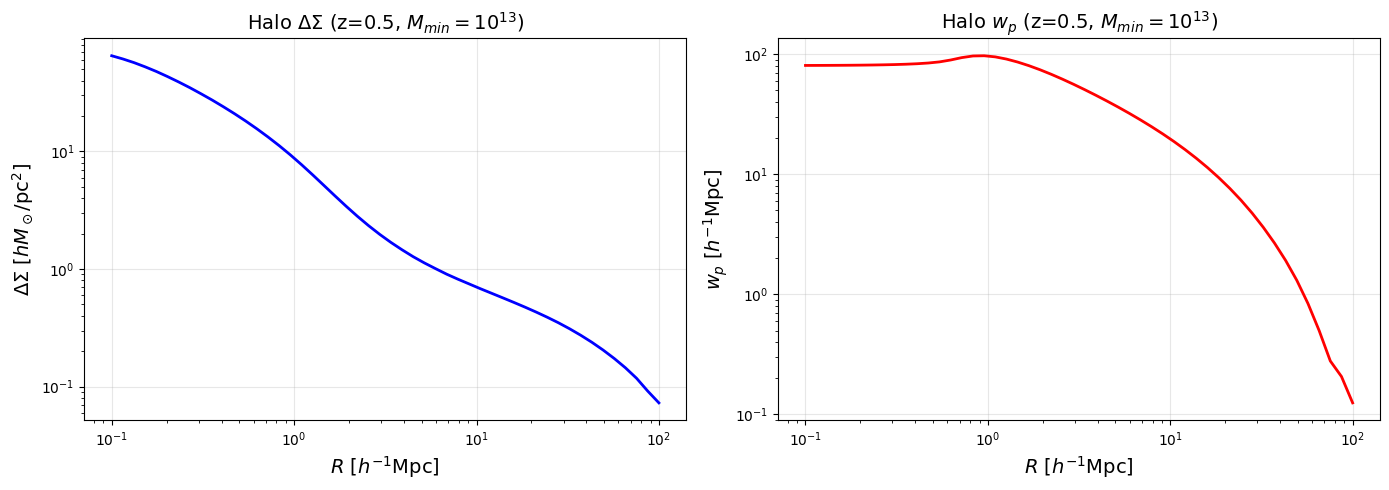

In [12]:
# ΔΣ and w_p for mass-threshold halo samples
R = np.logspace(-1, 2, 50)  # h^-1 Mpc
z = 0.5
M_min = 1e13  # h^-1 M_sun

ds_halo = pert_halo.delta_sigma_halo(R, z, M_min)
wp_halo = pert_halo.projected_correlation_halo(R, z, M_min)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].loglog(R, ds_halo, 'b-', lw=2)
axes[0].set_xlabel(r'$R$ [$h^{-1}$Mpc]', fontsize=14)
axes[0].set_ylabel(r'$\Delta\Sigma$ [$h M_\odot$/pc$^2$]', fontsize=14)
axes[0].set_title(f'Halo ΔΣ (z={z}, $M_{{min}}=10^{{{np.log10(M_min):.0f}}}$)', fontsize=14)
axes[0].grid(True, alpha=0.3)

axes[1].loglog(R, wp_halo, 'r-', lw=2)
axes[1].set_xlabel(r'$R$ [$h^{-1}$Mpc]', fontsize=14)
axes[1].set_ylabel(r'$w_p$ [$h^{-1}$Mpc]', fontsize=14)
axes[1].set_title(f'Halo $w_p$ (z={z}, $M_{{min}}=10^{{{np.log10(M_min):.0f}}}$)', fontsize=14)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 4. DarkEmuHODPerturbations

The main class for HSC-style 3×2pt analysis with HOD modeling.

**HOD Parameters** (Zheng et al. 2007 model):
- `logMmin`: Minimum halo mass for central galaxies
- `sigma_sq`: Scatter in central occupation
- `logM1`: Characteristic mass for satellites
- `alpha`: Power-law slope for satellites
- `kappa`: Satellite threshold parameter
- `poff`: Off-centering fraction
- `Roff`: Off-centering scale

**Available methods:**
- `delta_sigma(R, z)` - Galaxy-galaxy lensing ΔΣ(R)
- `projected_correlation(R, z, pimax)` - Galaxy clustering w_p(R)
- `galaxy_galaxy_correlation(r, z)` - 3D ξ_gg(r)
- `galaxy_matter_correlation(r, z)` - 3D ξ_gm(r)
- `*_components()` - Breakdown by 1h/2h terms

In [13]:
# Define HOD parameters (HSC-like LOWZ sample)
hod_params = DarkEmuHODParameters(
    logMmin=13.0,   # log10(M_min / [h^-1 M_sun])
    sigma_sq=0.3,   # Scatter in central occupation
    logM1=14.0,     # log10(M_1 / [h^-1 M_sun])
    alpha=1.0,      # Satellite power-law slope
    kappa=1.0,      # Satellite threshold
    poff=0.0,       # Off-centering fraction (0 = all centered)
    Roff=0.0,       # Off-centering scale
)

print("HOD Parameters:")
print(f"  logMmin  = {hod_params.logMmin}")
print(f"  sigma_sq = {hod_params.sigma_sq}")
print(f"  logM1    = {hod_params.logM1}")
print(f"  alpha    = {hod_params.alpha}")
print(f"  kappa    = {hod_params.kappa}")

HOD Parameters:
  logMmin  = 13.0
  sigma_sq = 0.3
  logM1    = 14.0
  alpha    = 1.0
  kappa    = 1.0


In [14]:
# Initialize DarkEmuHODPerturbations
z_lens = 0.5

pert_hod = DarkEmuHODPerturbations(
    background=background,
    redshifts=np.array([z_lens]),
    hod_params=hod_params,
)

print(f"DarkEmuHODPerturbations initialized at z = {z_lens}")

DarkEmuHODPerturbations initialized at z = 0.5


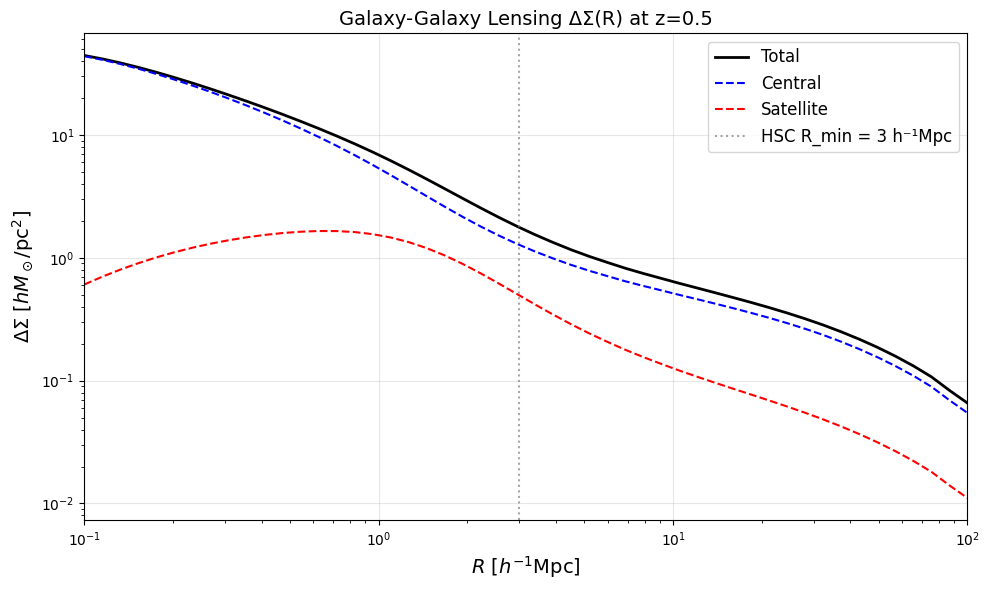

In [15]:
# Galaxy-Galaxy Lensing: ΔΣ(R)
R = np.logspace(-1, 2, 50)  # h^-1 Mpc

ds = pert_hod.delta_sigma(R, z_lens)
ds_components = pert_hod.delta_sigma_components(R, z_lens)

fig, ax = plt.subplots(figsize=(10, 6))

ax.loglog(R, ds_components['total'], 'k-', lw=2, label='Total')
ax.loglog(R, ds_components['central'], 'b--', lw=1.5, label='Central')
ax.loglog(R, ds_components['satellite'], 'r--', lw=1.5, label='Satellite')

ax.axvline(3.0, color='gray', ls=':', alpha=0.7, label='HSC R_min = 3 h⁻¹Mpc')

ax.set_xlabel(r'$R$ [$h^{-1}$Mpc]', fontsize=14)
ax.set_ylabel(r'$\Delta\Sigma$ [$h M_\odot$/pc$^2$]', fontsize=14)
ax.set_title(f'Galaxy-Galaxy Lensing ΔΣ(R) at z={z_lens}', fontsize=14)
ax.legend(fontsize=12)
ax.set_xlim(0.1, 100)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

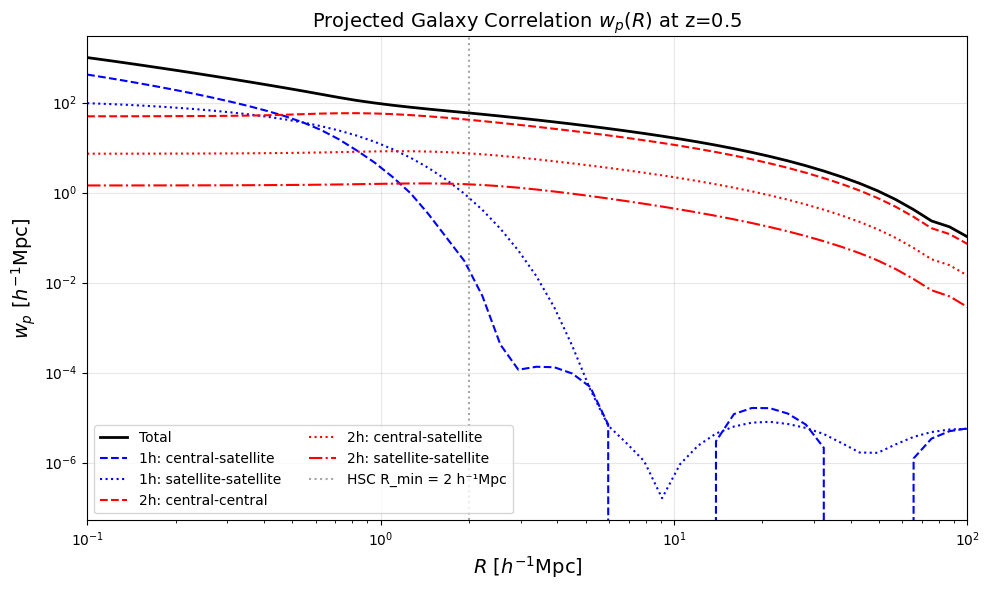

In [16]:
# Galaxy Clustering: w_p(R)
wp = pert_hod.projected_correlation(R, z_lens, pimax=100.0)
wp_components = pert_hod.projected_correlation_components(R, z_lens)

fig, ax = plt.subplots(figsize=(10, 6))

ax.loglog(R, wp_components['total'], 'k-', lw=2, label='Total')
ax.loglog(R, wp_components['1h_cs'], 'b--', lw=1.5, label='1h: central-satellite')
ax.loglog(R, wp_components['1h_ss'], 'b:', lw=1.5, label='1h: satellite-satellite')
ax.loglog(R, wp_components['2h_cc'], 'r--', lw=1.5, label='2h: central-central')
ax.loglog(R, wp_components['2h_cs'], 'r:', lw=1.5, label='2h: central-satellite')
ax.loglog(R, wp_components['2h_ss'], 'r-.', lw=1.5, label='2h: satellite-satellite')

ax.axvline(2.0, color='gray', ls=':', alpha=0.7, label='HSC R_min = 2 h⁻¹Mpc')

ax.set_xlabel(r'$R$ [$h^{-1}$Mpc]', fontsize=14)
ax.set_ylabel(r'$w_p$ [$h^{-1}$Mpc]', fontsize=14)
ax.set_title(f'Projected Galaxy Correlation $w_p(R)$ at z={z_lens}', fontsize=14)
ax.legend(fontsize=10, ncol=2)
ax.set_xlim(0.1, 100)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

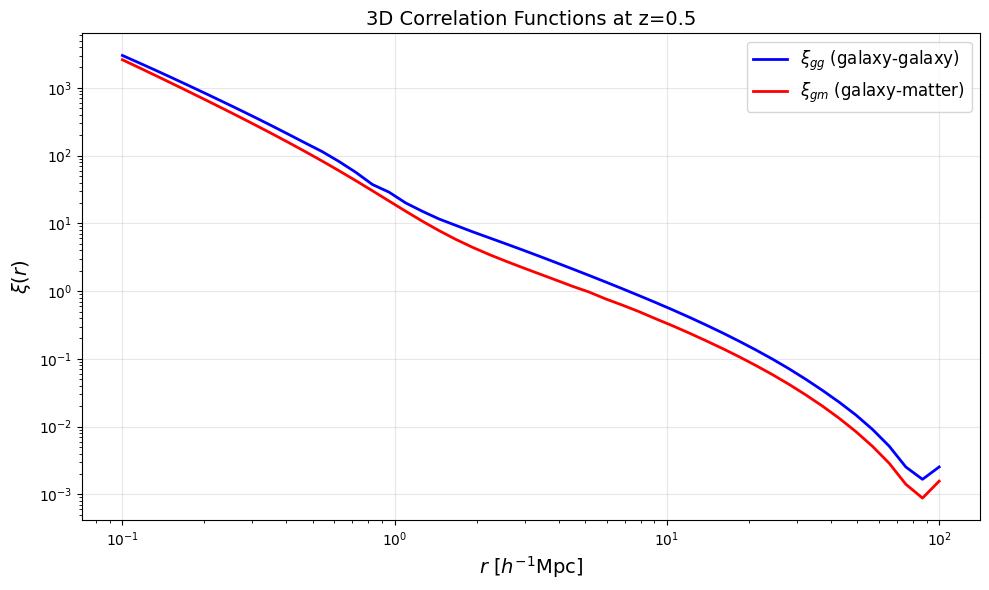

In [17]:
# 3D Correlation Functions: ξ_gg and ξ_gm
r = np.logspace(-1, 2, 50)  # h^-1 Mpc

xi_gg = pert_hod.galaxy_galaxy_correlation(r, z_lens)
xi_gm = pert_hod.galaxy_matter_correlation(r, z_lens)

fig, ax = plt.subplots(figsize=(10, 6))

ax.loglog(r, xi_gg, 'b-', lw=2, label=r'$\xi_{gg}$ (galaxy-galaxy)')
ax.loglog(r, xi_gm, 'r-', lw=2, label=r'$\xi_{gm}$ (galaxy-matter)')

ax.set_xlabel(r'$r$ [$h^{-1}$Mpc]', fontsize=14)
ax.set_ylabel(r'$\xi(r)$', fontsize=14)
ax.set_title(f'3D Correlation Functions at z={z_lens}', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 5. Changing HOD Parameters

The `set_hod()` method allows fast updates of HOD parameters without re-initializing the cosmology.

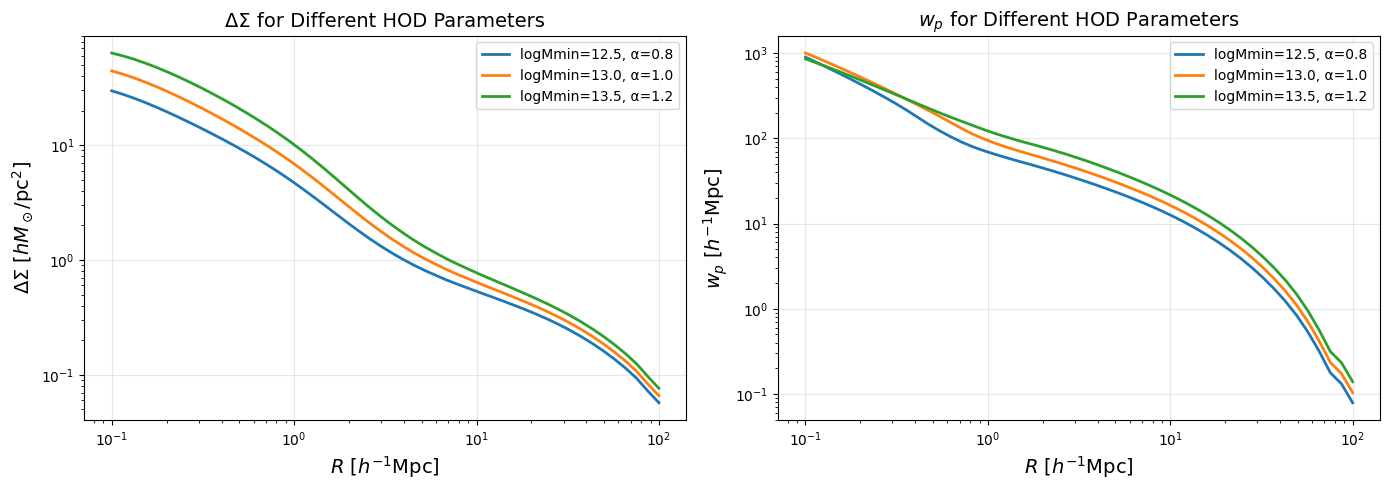

In [18]:
# Compare different HOD parameter sets
R = np.logspace(-1, 2, 50)

hod_sets = [
    {'logMmin': 12.5, 'sigma_sq': 0.2, 'logM1': 13.5, 'alpha': 0.8, 'kappa': 1.0, 'poff': 0.0, 'Roff': 0.0},
    {'logMmin': 13.0, 'sigma_sq': 0.3, 'logM1': 14.0, 'alpha': 1.0, 'kappa': 1.0, 'poff': 0.0, 'Roff': 0.0},
    {'logMmin': 13.5, 'sigma_sq': 0.4, 'logM1': 14.5, 'alpha': 1.2, 'kappa': 1.0, 'poff': 0.0, 'Roff': 0.0},
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, hod_dict in enumerate(hod_sets):
    hod = DarkEmuHODParameters(**hod_dict)
    pert_hod.set_hod(hod)  # Fast HOD update
    
    ds = pert_hod.delta_sigma(R, z_lens)
    wp = pert_hod.projected_correlation(R, z_lens)
    
    label = f"logMmin={hod_dict['logMmin']}, α={hod_dict['alpha']}"
    axes[0].loglog(R, ds, lw=2, label=label)
    axes[1].loglog(R, wp, lw=2, label=label)

axes[0].set_xlabel(r'$R$ [$h^{-1}$Mpc]', fontsize=14)
axes[0].set_ylabel(r'$\Delta\Sigma$ [$h M_\odot$/pc$^2$]', fontsize=14)
axes[0].set_title('ΔΣ for Different HOD Parameters', fontsize=14)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel(r'$R$ [$h^{-1}$Mpc]', fontsize=14)
axes[1].set_ylabel(r'$w_p$ [$h^{-1}$Mpc]', fontsize=14)
axes[1].set_title('$w_p$ for Different HOD Parameters', fontsize=14)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 6. Cosmology Dependence

Compare predictions for different cosmological parameters.

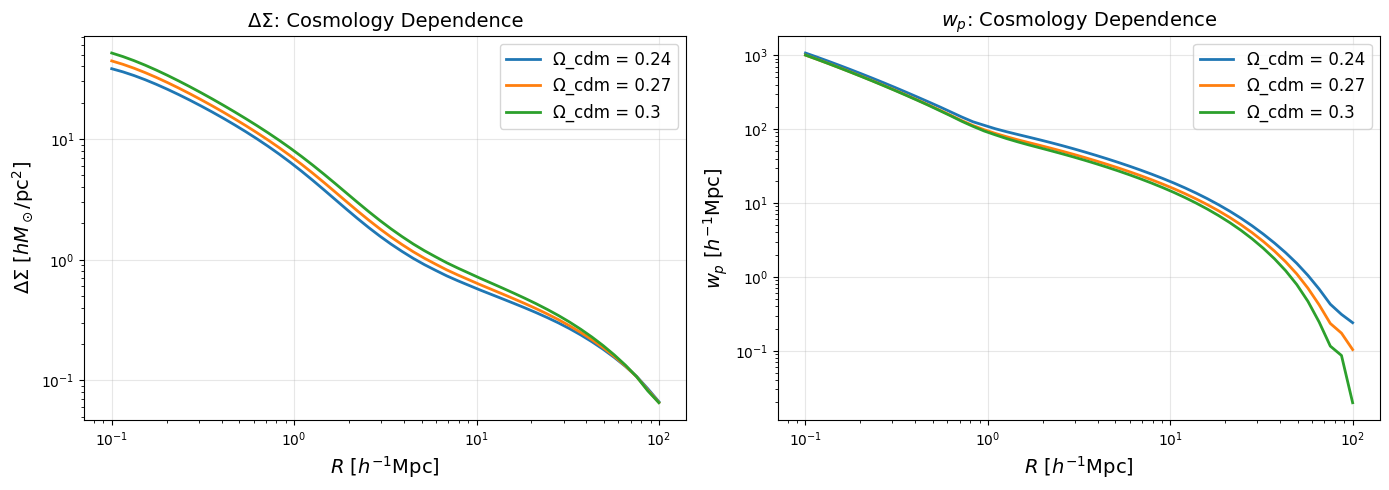

In [19]:
# Compare different Omega_cdm values
Omega_cdm_values = [0.24, 0.27, 0.30]
R = np.logspace(-1, 2, 50)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for Omega_cdm in Omega_cdm_values:
    # Create new background
    params = cosmo_params.copy()
    params['Omega_cdm0'] = Omega_cdm
    bg = CAMBBackground(**params)
    
    # Create perturbations
    pert = DarkEmuHODPerturbations(
        background=bg,
        redshifts=np.array([z_lens]),
        hod_params=hod_params,
        validate_params=False,  # Skip validation for speed
    )
    
    ds = pert.delta_sigma(R, z_lens)
    wp = pert.projected_correlation(R, z_lens)
    
    label = f'Ω_cdm = {Omega_cdm}'
    axes[0].loglog(R, ds, lw=2, label=label)
    axes[1].loglog(R, wp, lw=2, label=label)

axes[0].set_xlabel(r'$R$ [$h^{-1}$Mpc]', fontsize=14)
axes[0].set_ylabel(r'$\Delta\Sigma$ [$h M_\odot$/pc$^2$]', fontsize=14)
axes[0].set_title('ΔΣ: Cosmology Dependence', fontsize=14)
axes[0].legend(fontsize=12)
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel(r'$R$ [$h^{-1}$Mpc]', fontsize=14)
axes[1].set_ylabel(r'$w_p$ [$h^{-1}$Mpc]', fontsize=14)
axes[1].set_title('$w_p$: Cosmology Dependence', fontsize=14)
axes[1].legend(fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 7. Summary: Class Hierarchy

```
DarkEmuNonLinearPerturbations
├── matter_power_spectrum(z, k)  → P(k,z)
├── growth_factor(z)             → D(z)
├── growth_rate(z)               → f(z)
└── get_sigma8(z)                → σ8(z)
        │
        ▼
DarkEmuHaloPerturbations (inherits above)
├── halo_matter_correlation(r, z, M_min)   → ξ_hm
├── halo_halo_correlation(r, z, M_min)     → ξ_hh
├── halo_mass_function(z)                  → dn/dlnM
├── halo_bias(M_min, z)                    → b(M)
├── delta_sigma_halo(R, z, M_min)          → ΔΣ_halo
└── projected_correlation_halo(R, z, M_min) → w_p,halo
        │
        ▼
DarkEmuHODPerturbations (inherits above + HOD)
├── delta_sigma(R, z)              → ΔΣ_gal (GGL)
├── projected_correlation(R, z)    → w_p,gal (GC)
├── galaxy_galaxy_correlation(r, z) → ξ_gg
├── galaxy_matter_correlation(r, z) → ξ_gm
└── set_hod(hod_params)            → Fast HOD update
```

### Next steps

| Topic | Notebook / Script |
|-------|-------------------|
| Why we use Dark Emulator for w_p, ΔΣ | `dark_emulator_observables_usage.ipynb` |
| GC only (w_p fitting) | `fitting_gc_wp.ipynb` |
| GGL only (ΔΣ fitting) | `fitting_ggl_delta_sigma.ipynb` |
| 3x2pt (GC+GGL+WL) short run | `fitting_3x2pt.ipynb` |
| 3x2pt production (script) | `playground/scripts/sampling/darkemu_3x2pt_full_sampling.py` |

In [23]:
print("Tutorial complete!")
print()
print("Next steps:")
print("  • Observables (why w_p, ΔΣ from Dark Emulator): playground/tutorials/dark_emulator/dark_emulator_observables_usage.ipynb")
print("  • GC only (w_p fitting):                        playground/tutorials/dark_emulator/fitting_gc_wp.ipynb")
print("  • GGL only (ΔΣ fitting):                        playground/tutorials/dark_emulator/fitting_ggl_delta_sigma.ipynb")
print("  • 3x2pt (GC+GGL+WL):                            playground/tutorials/dark_emulator/fitting_3x2pt.ipynb")
print("  • 3x2pt production run:                         playground/scripts/sampling/darkemu_3x2pt_full_sampling.py")

Tutorial complete!

Next steps:
  • Observables (why w_p, ΔΣ from Dark Emulator): playground/tutorials/dark_emulator/dark_emulator_observables_usage.ipynb
  • GC only (w_p fitting):                        playground/tutorials/dark_emulator/fitting_gc_wp.ipynb
  • GGL only (ΔΣ fitting):                        playground/tutorials/dark_emulator/fitting_ggl_delta_sigma.ipynb
  • 3x2pt (GC+GGL+WL):                            playground/tutorials/dark_emulator/fitting_3x2pt.ipynb
  • 3x2pt production run:                         playground/scripts/sampling/darkemu_3x2pt_full_sampling.py
